# Notebook 13 — Sensitivity Analysis on Missingness Threshold

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

Tests the sensitivity of the clustering pipeline to the Tier 1 missingness threshold used to select eligible variables. The main analysis uses 50%; here we sweep 30%–70% and track how the number of eligible variables, domains, clusters, silhouette, and noise fraction change.

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

DATA_DIR = '../data'
RESULTS_DIR = '../results'
FIGURES_DIR = '../report template/Figures'

THRESHOLDS = [30, 40, 50, 60, 70]

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load raw data and domain mapping
df = pd.read_excel(os.path.join(DATA_DIR, '0_tests2.xlsx'))
print(f'Raw dataset: {df.shape}')

# Load best params from infrastructure
with open(os.path.join(RESULTS_DIR, 'shared_infrastructure.pkl'), 'rb') as f:
    infra = pickle.load(f)

BEST_UMAP_PARAMS = infra['BEST_UMAP_PARAMS']
BEST_HDBSCAN_PARAMS = infra['BEST_HDBSCAN_PARAMS']

# Full domain mapping (all cognitive variables)
DOMAINS_FULL = {
    'Orientation': [c for c in df.columns if c.startswith('O')],
    'Attention': [c for c in df.columns if c.startswith('A')],
    'Visuoperception': [c for c in df.columns if c.startswith('VP')],
    'Language': [c for c in df.columns if c.startswith('L')],
    'Visuoconstruction': [c for c in df.columns if c.startswith('VC')],
    'Memory': [c for c in df.columns if c.startswith('M')],
    'Executive Function': [c for c in df.columns if c.startswith('FE')]
}

# Exclude non-cognitive vars sharing a domain prefix (e.g. AGE_INJURY -> 'A')
NON_COGNITIVE_VARS = {'AGE_INJURY'}
HIGHER_WORSE = {'ATMTA'}  # timed tests: higher = worse (sign-reversed)
DOMAINS_FULL = {d: [c for c in v if c not in NON_COGNITIVE_VARS]
                for d, v in DOMAINS_FULL.items()}

all_cognitive_vars = []
for variables in DOMAINS_FULL.values():
    all_cognitive_vars.extend(variables)

print(f'Total cognitive variables: {len(all_cognitive_vars)}')
print(f'UMAP params: {BEST_UMAP_PARAMS}')
print(f'HDBSCAN params: {BEST_HDBSCAN_PARAMS}')

Raw dataset: (22075, 31)
Total cognitive variables: 25
UMAP params: {'n_components': 3, 'n_neighbors': 15, 'min_dist': 0.0}
HDBSCAN params: {'min_cluster_size': 2000, 'min_samples': 5, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.0}


## 1. Sweep Missingness Thresholds

In [3]:
# Per-variable missingness
miss_pct = df[all_cognitive_vars].isnull().mean() * 100

results = []

for threshold in THRESHOLDS:
    print(f'\n{"="*60}')
    print(f'Threshold: {threshold}%')
    print(f'{"="*60}')
    
    # 1. Filter variables by threshold
    eligible_vars = [v for v in all_cognitive_vars if miss_pct[v] < threshold]
    print(f'Eligible variables: {len(eligible_vars)}')
    
    if len(eligible_vars) < 3:
        print('  Too few variables, skipping.')
        results.append({
            'threshold': threshold, 'n_vars': len(eligible_vars),
            'n_domains': 0, 'n_samples': 0, 'n_clusters': 0,
            'silhouette': -1, 'noise_fraction': 1.0
        })
        continue
    
    # 2. Map to domains
    domains = {}
    for domain, variables in DOMAINS_FULL.items():
        eligible_in_domain = [v for v in variables if v in eligible_vars]
        if eligible_in_domain:
            domains[domain] = eligible_in_domain
    
    print(f'Active domains: {len(domains)} — {list(domains.keys())}')
    for d, vs in domains.items():
        print(f'  {d}: {vs}')
    
    # 3. Filter rows (at least 1 non-missing among eligible vars)
    mask_valid = df[eligible_vars].notna().any(axis=1)
    df_subset = df.loc[mask_valid].copy()
    X = df_subset[eligible_vars].copy()
    print(f'Samples: {len(X)}')
    
    # 4. MICE imputation (5 iterations, pooled)
    print('  Imputing with MICE...')
    m = 5
    mice_imps = []
    for i in range(m):
        imputer = IterativeImputer(
            estimator=BayesianRidge(),
            max_iter=10,
            sample_posterior=True,
            random_state=RANDOM_STATE + i
        )
        X_imp_i = pd.DataFrame(
            imputer.fit_transform(X), columns=eligible_vars, index=X.index
        )
        mice_imps.append(X_imp_i)
    X_imputed = pd.concat(mice_imps).groupby(level=0).mean()
    print(f'  Imputation complete. Missing remaining: {X_imputed.isnull().sum().sum()}')
    
    # 5. Compute domain scores
    # Corrected aggregation: winsorise, sign-flip timed tests, z-standardise, weighted avg
    Xc = X_imputed.copy()
    for v in Xc.columns:
        lo, hi = Xc[v].quantile([0.01, 0.99]); Xc[v] = Xc[v].clip(lo, hi)
        if v in HIGHER_WORSE: Xc[v] = -Xc[v]
    Zc = pd.DataFrame(StandardScaler().fit_transform(Xc), columns=Xc.columns, index=Xc.index)
    wts = {v: 1.0 - miss_pct[v]/100.0 for v in eligible_vars}
    domain_scores = pd.DataFrame(index=X_imputed.index)
    for domain, variables in domains.items():
        wv = np.array([wts[v] for v in variables]); wv = wv / wv.sum()
        domain_scores[domain] = (Zc[variables].values * wv).sum(axis=1)
    print(f'  Domain scores shape: {domain_scores.shape}')
    
    # 6. Standardise + UMAP + HDBSCAN
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(domain_scores)
    
    # Adjust UMAP n_components if fewer domains
    n_comp = min(BEST_UMAP_PARAMS['n_components'], domain_scores.shape[1] - 1)
    n_comp = max(n_comp, 2)
    
    reducer = umap.UMAP(
        n_components=n_comp,
        n_neighbors=BEST_UMAP_PARAMS['n_neighbors'],
        min_dist=BEST_UMAP_PARAMS['min_dist'],
        random_state=RANDOM_STATE
    )
    embedding = reducer.fit_transform(X_scaled)
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=BEST_HDBSCAN_PARAMS['min_cluster_size'],
        min_samples=BEST_HDBSCAN_PARAMS['min_samples'],
        cluster_selection_method=BEST_HDBSCAN_PARAMS['cluster_selection_method'],
        cluster_selection_epsilon=BEST_HDBSCAN_PARAMS['cluster_selection_epsilon']
    )
    labels = clusterer.fit_predict(embedding)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).mean()
    mask_clustered = labels >= 0
    sil = silhouette_score(embedding[mask_clustered], labels[mask_clustered]) if n_clusters >= 2 else -1
    
    print(f'  Clusters: {n_clusters}, Silhouette: {sil:.4f}, Noise: {noise_frac:.1%}')
    
    results.append({
        'threshold': threshold,
        'n_vars': len(eligible_vars),
        'n_domains': len(domains),
        'n_samples': len(X),
        'n_clusters': n_clusters,
        'silhouette': round(sil, 4),
        'noise_fraction': round(noise_frac, 4),
        'umap_n_components': n_comp,
        'domains_active': list(domains.keys()),
        'eligible_vars': eligible_vars
    })

print(f'\nAll {len(THRESHOLDS)} thresholds processed.')


Threshold: 30%
Eligible variables: 5
Active domains: 3 — ['Orientation', 'Attention', 'Memory']
  Orientation: ['OPERSONA', 'OESPAI', 'OTEMPS']
  Attention: ['ASPAN']
  Memory: ['MRAVLT075']
Samples: 17324
  Imputing with MICE...


  Imputation complete. Missing remaining: 0
  Domain scores shape: (17324, 3)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  Clusters: 0, Silhouette: -1.0000, Noise: 100.0%

Threshold: 40%
Eligible variables: 12
Active domains: 5 — ['Orientation', 'Attention', 'Language', 'Memory', 'Executive Function']
  Orientation: ['OPERSONA', 'OESPAI', 'OTEMPS']
  Attention: ['ASPAN']
  Language: ['LREPETICIOTB', 'LDENOMINACIOTB', 'LCOMPRENSIOTB']
  Memory: ['MDIGITS', 'MRAVLT075', 'MRAVLT015', 'MRAVLT015R']
  Executive Function: ['FEPMR']
Samples: 17388
  Imputing with MICE...


  Imputation complete. Missing remaining: 0
  Domain scores shape: (17388, 5)


...

  Clusters: 2, Silhouette: 0.3946, Noise: 20.4%

Threshold: 60%
Eligible variables: 16
Active domains: 7 — ['Orientation', 'Attention', 'Visuoperception', 'Language', 'Visuoconstruction', 'Memory', 'Executive Function']
  Orientation: ['OPERSONA', 'OESPAI', 'OTEMPS']
  Attention: ['ASPAN', 'ATMTA']
  Visuoperception: ['VPIMATGES']
  Language: ['LREPETICIOTB', 'LDENOMINACIOTB', 'LCOMPRENSIOTB']
  Visuoconstruction: ['VCCUBS']
  Memory: ['MDIGITS', 'MLLETRES', 'MRAVLT075', 'MRAVLT015', 'MRAVLT015R']
  Executive Function: ['FEPMR']
Samples: 17407
  Imputing with MICE...


  Imputation complete. Missing remaining: 0
  Domain scores shape: (17407, 7)


  Clusters: 2, Silhouette: 0.5192, Noise: 30.0%

Threshold: 70%
Eligible variables: 18
Active domains: 7 — ['Orientation', 'Attention', 'Visuoperception', 'Language', 'Visuoconstruction', 'Memory', 'Executive Function']
  Orientation: ['OPERSONA', 'OESPAI', 'OTEMPS']
  Attention: ['ASPAN', 'ATMTA']
  Visuoperception: ['VPWAISIII', 'VPIMATGES']
  Language: ['LREPETICIOTB', 'LDENOMINACIOTB', 'LCOMPRENSIOTB']
  Visuoconstruction: ['VCCUBS']
  Memory: ['MDIGITS', 'MLLETRES', 'MRAVLT075', 'MRAVLT015', 'MRAVLT015R']
  Executive Function: ['FETMTB', 'FEPMR']
Samples: 17407
  Imputing with MICE...


  Imputation complete. Missing remaining: 0
  Domain scores shape: (17407, 7)


  Clusters: 2, Silhouette: 0.4595, Noise: 25.8%

All 5 thresholds processed.


## 2. Results Summary

In [4]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('domains_active', 'eligible_vars')} 
                            for r in results])
print('=== Sensitivity Analysis Results ===')
print(results_df.to_string(index=False))

results_df.to_csv(os.path.join(RESULTS_DIR, 'Sensitivity_Analysis.csv'), index=False)
print('\nSaved: Sensitivity_Analysis.csv')

=== Sensitivity Analysis Results ===
 threshold  n_vars  n_domains  n_samples  n_clusters  silhouette  noise_fraction  umap_n_components
        30       5          3      17324           0     -1.0000          1.0000                  2
        40      12          5      17388           3      0.3986          0.0501                  3
        50      14          6      17406           2      0.3946          0.2036                  3
        60      16          7      17407           2      0.5192          0.3001                  3
        70      18          7      17407           2      0.4595          0.2578                  3

Saved: Sensitivity_Analysis.csv


## 3. Publication-Quality Figure

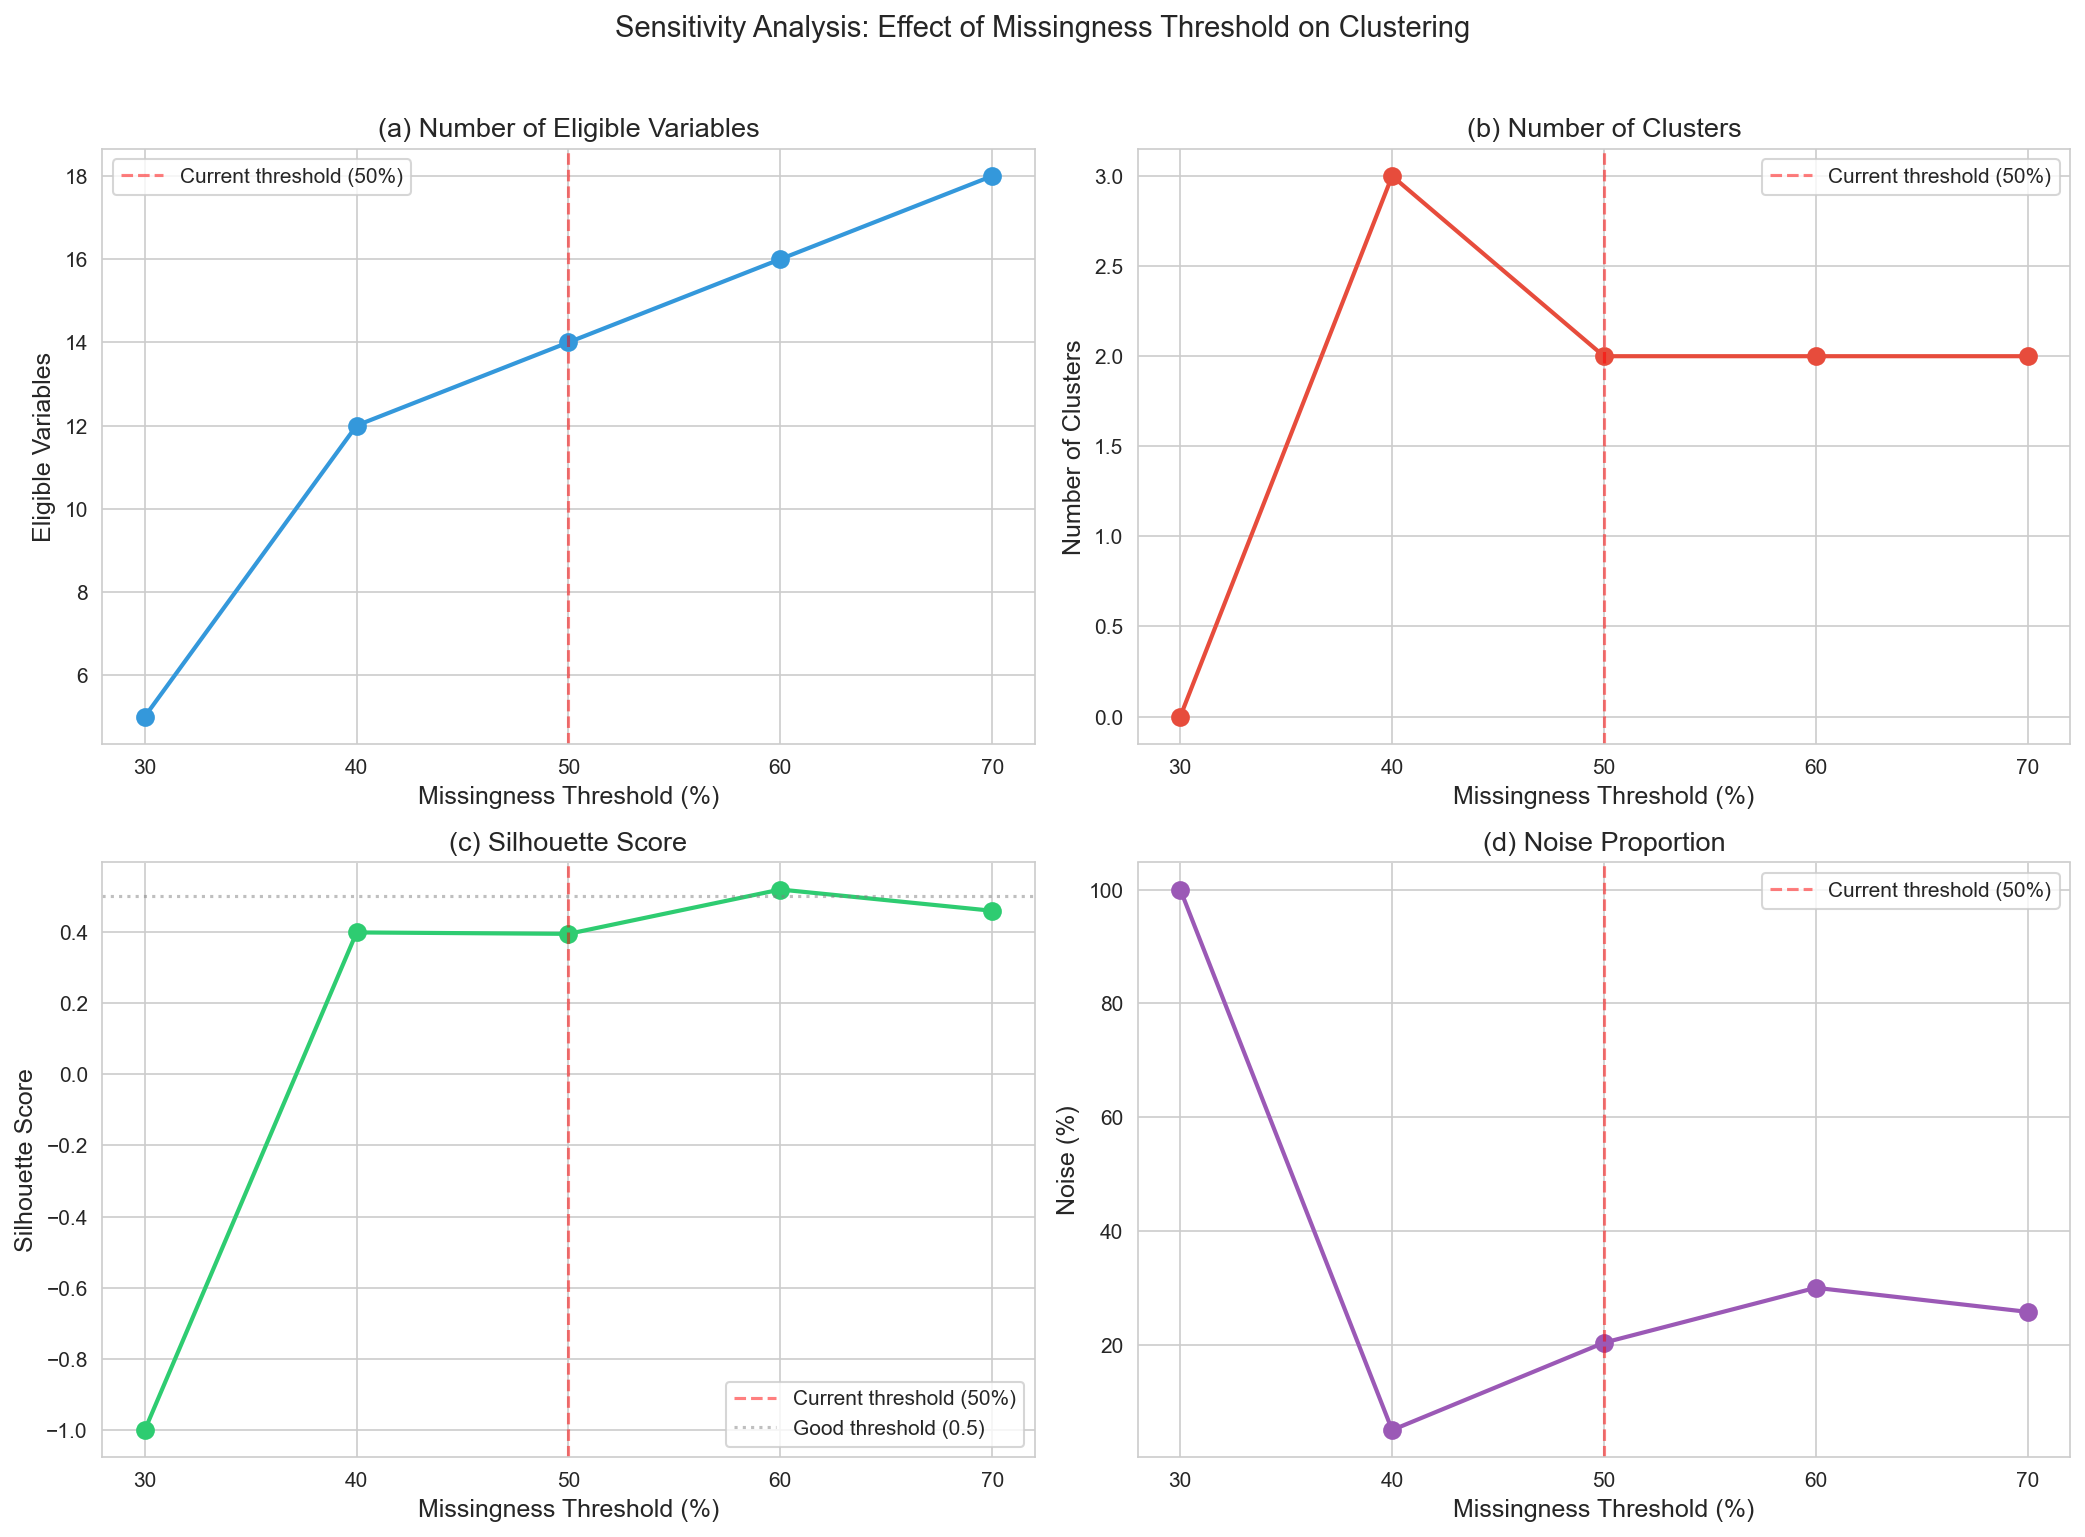

Saved: sensitivity_analysis.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

thresholds = results_df['threshold'].values
marker_kwargs = dict(marker='o', markersize=8, linewidth=2)

# Panel 1: Number of eligible variables
ax = axes[0, 0]
ax.plot(thresholds, results_df['n_vars'], color='#3498db', **marker_kwargs)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Current threshold (50%)')
ax.set_xlabel('Missingness Threshold (%)', fontsize=12)
ax.set_ylabel('Eligible Variables', fontsize=12)
ax.set_title('(a) Number of Eligible Variables', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(thresholds)

# Panel 2: Number of clusters
ax = axes[0, 1]
ax.plot(thresholds, results_df['n_clusters'], color='#e74c3c', **marker_kwargs)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Current threshold (50%)')
ax.set_xlabel('Missingness Threshold (%)', fontsize=12)
ax.set_ylabel('Number of Clusters', fontsize=12)
ax.set_title('(b) Number of Clusters', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(thresholds)

# Panel 3: Silhouette score
ax = axes[1, 0]
ax.plot(thresholds, results_df['silhouette'], color='#2ecc71', **marker_kwargs)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Current threshold (50%)')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Good threshold (0.5)')
ax.set_xlabel('Missingness Threshold (%)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('(c) Silhouette Score', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(thresholds)

# Panel 4: Noise fraction
ax = axes[1, 1]
ax.plot(thresholds, results_df['noise_fraction'] * 100, color='#9b59b6', **marker_kwargs)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Current threshold (50%)')
ax.set_xlabel('Missingness Threshold (%)', fontsize=12)
ax.set_ylabel('Noise (%)', fontsize=12)
ax.set_title('(d) Noise Proportion', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(thresholds)

plt.suptitle('Sensitivity Analysis: Effect of Missingness Threshold on Clustering', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sensitivity_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: sensitivity_analysis.png')

In [6]:
# Save full results
sensitivity_results = {
    'thresholds': THRESHOLDS,
    'results': results,
    'summary_df': results_df.to_dict('records'),
    'best_umap_params': BEST_UMAP_PARAMS,
    'best_hdbscan_params': BEST_HDBSCAN_PARAMS,
}

with open(os.path.join(RESULTS_DIR, 'sensitivity_analysis.pkl'), 'wb') as f:
    pickle.dump(sensitivity_results, f, protocol=4)

print('Saved: sensitivity_analysis.pkl')
print(f'\n=== Notebook 13 Complete ===')

Saved: sensitivity_analysis.pkl

=== Notebook 13 Complete ===
